## Section 4 — Exploratory Data Analysis

Three visualisations before training:

1. **Label distribution bar charts** — positive vs negative counts per condition in train and validation sets. Makes the class imbalance clearly visible.

2. **Label co-occurrence heatmap** — shows how often conditions appear together. Most ACL and meniscus tears also carry the abnormal label, which is clinically expected.

3. **Sample MRI slices** — shows 5 slices across all three planes for one exam. Red-bordered slices are selected by the top-K variance method used in preprocessing.


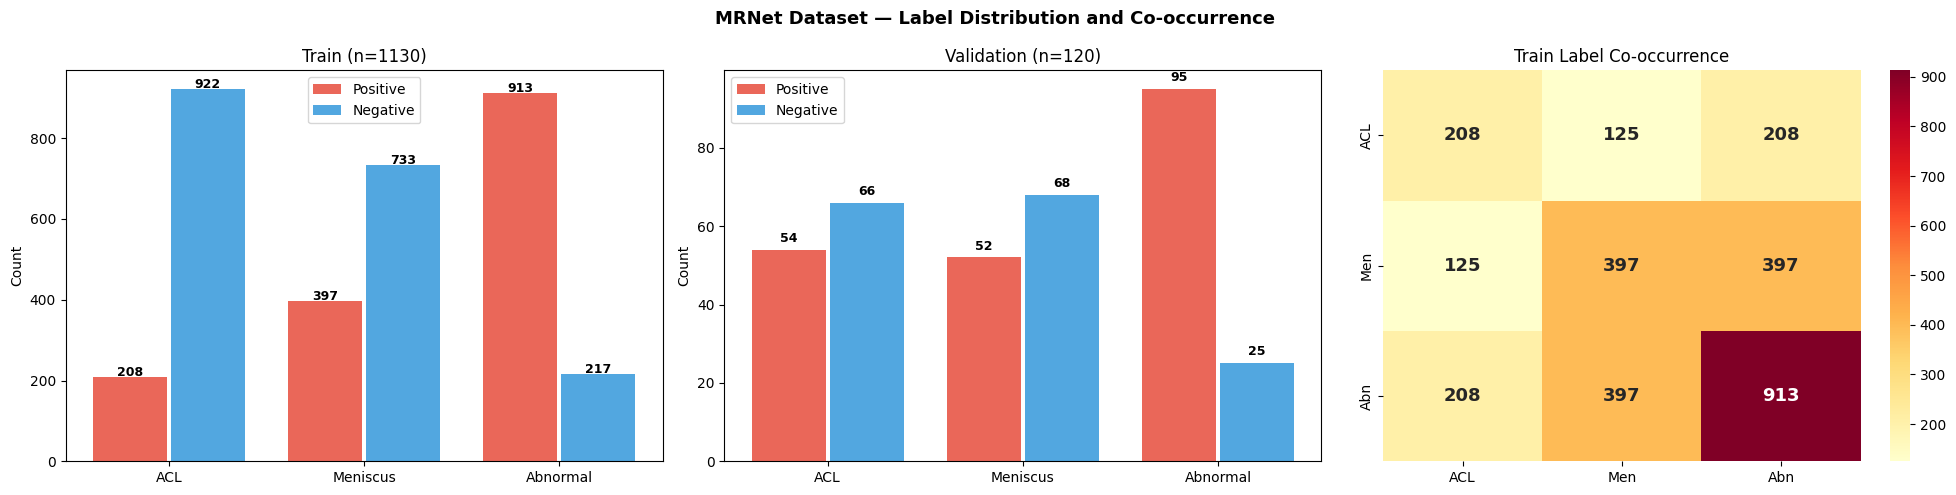

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("MRNet Dataset — Label Distribution and Co-occurrence", fontsize=13, fontweight="bold")

for ax, (name, df) in zip(axes[:2], [("Train", train_df), ("Validation", valid_df)]):
    counts = df[CFG.LABEL_NAMES].sum()
    neg    = len(df) - counts
    x = np.arange(3)
    bp = ax.bar(x - .2, counts, .38, label="Positive", color="#E74C3C", alpha=0.85)
    bn = ax.bar(x + .2, neg,    .38, label="Negative", color="#3498DB", alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(["ACL", "Meniscus", "Abnormal"])
    ax.set_title(f"{name} (n={len(df)})"); ax.set_ylabel("Count"); ax.legend()
    for bar in list(bp) + list(bn):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(int(bar.get_height())), ha="center", fontsize=9, fontweight="bold")

co = train_df[CFG.LABEL_NAMES].T.dot(train_df[CFG.LABEL_NAMES])
sns.heatmap(co, annot=True, fmt=".0f", cmap="YlOrRd", ax=axes[2],
            xticklabels=["ACL","Men","Abn"], yticklabels=["ACL","Men","Abn"],
            annot_kws={"size": 13, "weight": "bold"})
axes[2].set_title("Train Label Co-occurrence")
plt.tight_layout()
plt.savefig(CFG.OUT_DIR / "eda_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


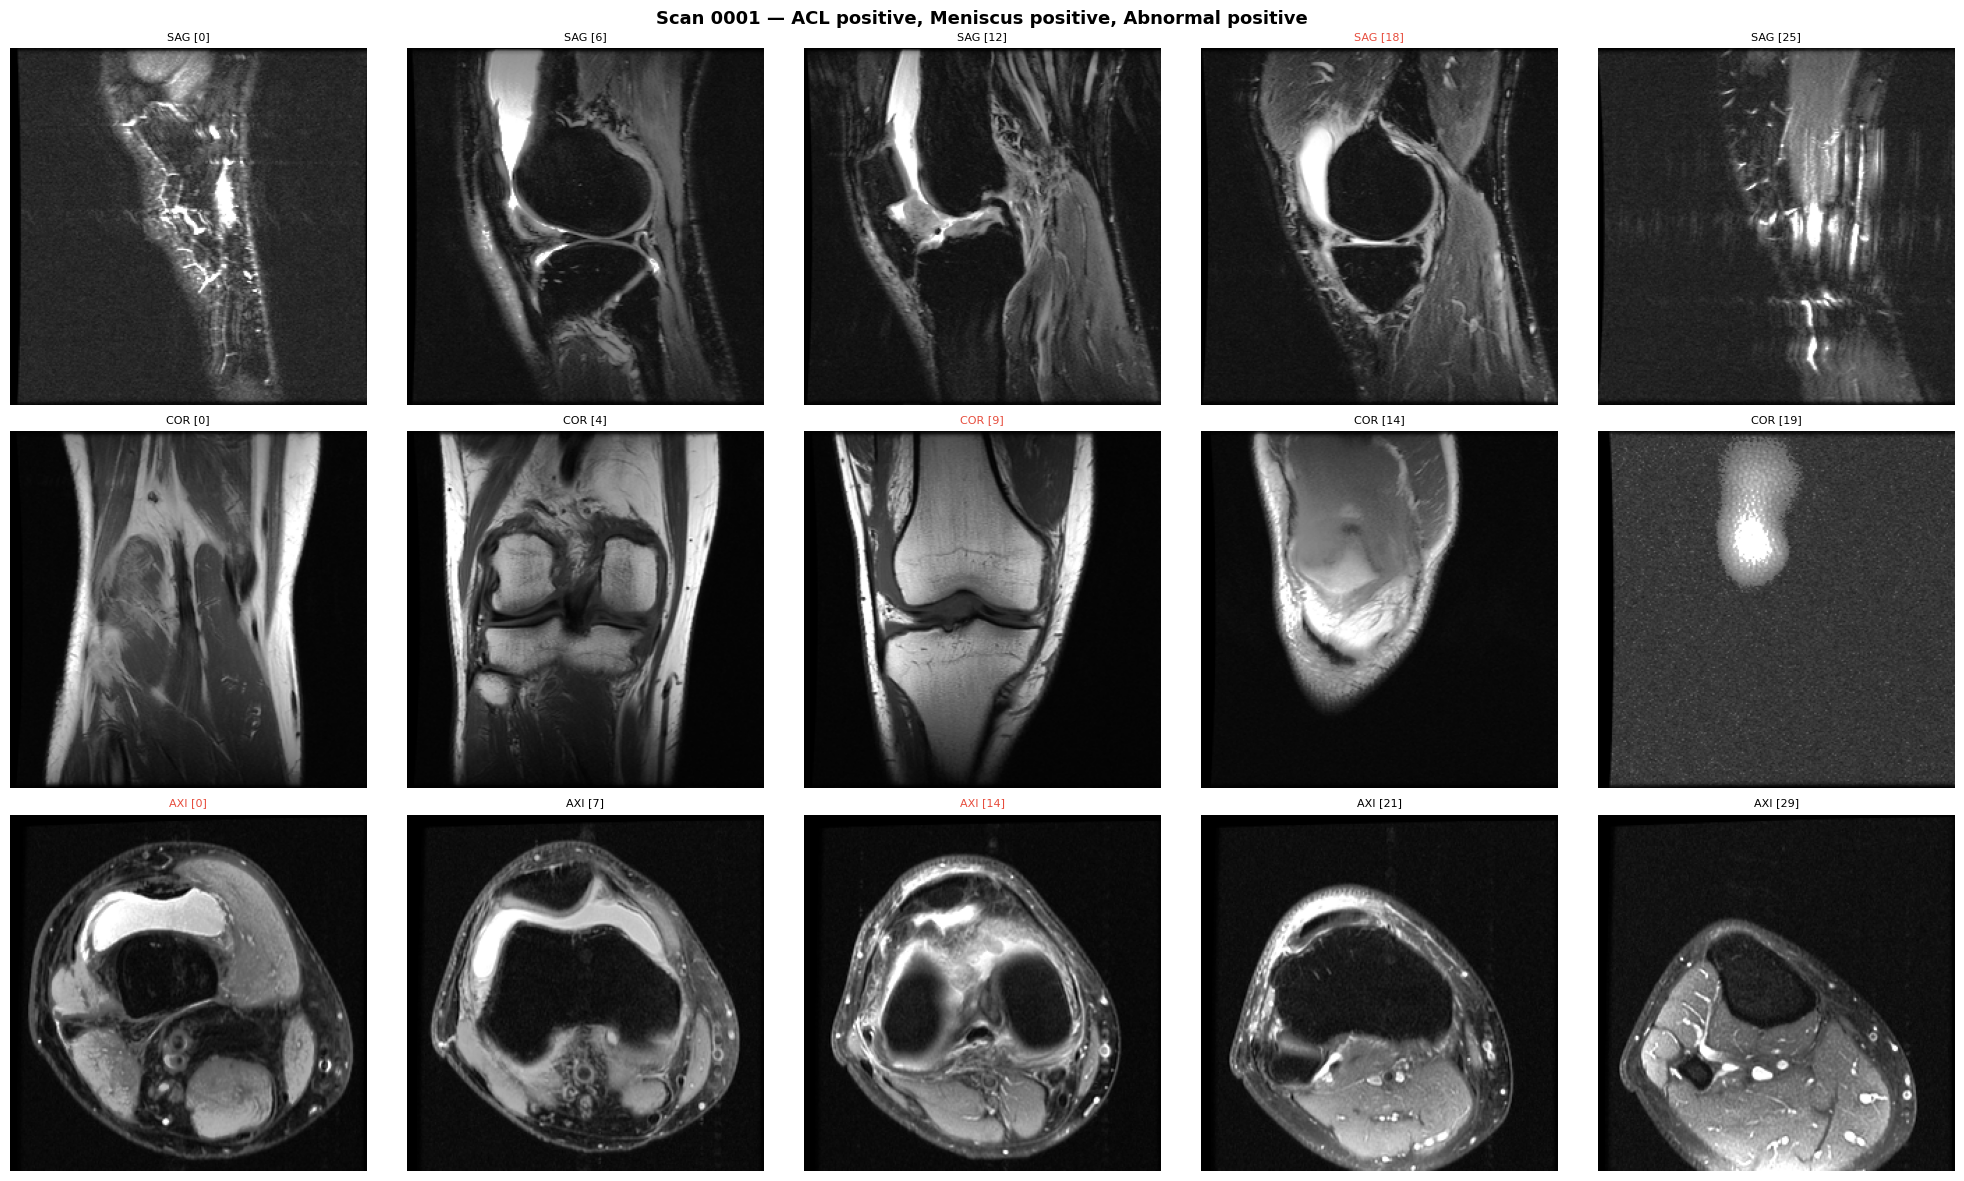

Red border = slice selected by top-K variance


In [7]:
sample_id = "0001"
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle(f"Scan {sample_id} — ACL positive, Meniscus positive, Abnormal positive",
             fontsize=13, fontweight="bold")

for row_i, plane in enumerate(["sagittal", "coronal", "axial"]):
    vol  = np.load(str(CFG.ROOT / "train" / plane / f"{sample_id}.npy"))
    D    = vol.shape[0]
    var  = np.var(vol.reshape(D, -1), axis=1)
    topk = np.sort(np.argsort(var)[-CFG.TOP_K_SLICES:])
    for col_i, idx in enumerate(np.linspace(0, D-1, 5, dtype=int)):
        ax = axes[row_i, col_i]
        ax.imshow(vol[idx], cmap="gray"); ax.axis("off")
        in_topk = any(abs(int(idx) - int(t)) <= 1 for t in topk)
        c = "#E74C3C" if in_topk else "white"
        for sp in ax.spines.values(): sp.set_edgecolor(c); sp.set_linewidth(3)
        ax.set_title(f"{plane[:3].upper()} [{idx}]",
                     fontsize=8, color="#E74C3C" if in_topk else "black")

plt.tight_layout()
plt.savefig(CFG.OUT_DIR / "eda_sample_slices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Red border = slice selected by top-K variance")


## Section 5 — Preprocessing and Dataset

**Slice selection:** Each MRI exam is a 3D volume with variable depth (typically 20-50 slices). We rank all slices by pixel variance and select the top-5 most informative. Three of these are chosen spread evenly and stacked as the R, G, B channels of a pseudo-RGB image. High-variance slices contain structural detail rather than blank background.

**Resizing:** Images are resized from 128x128 to 224x224 to match the input expected by pretrained ViT-Small weights.

**Training augmentation:**
- Random rotation up to 20 degrees
- Random translation up to 10% in X and Y
- Random scaling between 85% and 115%
- Random horizontal flip
- Colour jitter on brightness and contrast

No augmentation is applied during validation — only resize and normalise.

**MRNetDataset** loads all three planes per exam, converts each to a pseudo-RGB tensor, applies the transform, and returns (sagittal, coronal, axial, label, exam ID).


In [8]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def select_topk_variance_slices(volume, top_k=5, n_out=3):
    D    = volume.shape[0]
    var  = np.var(volume.reshape(D, -1), axis=1)
    topk = np.sort(np.argsort(var)[-min(top_k, D):])
    n_out = min(n_out, len(topk))
    chosen = topk[np.linspace(0, len(topk)-1, n_out, dtype=int)]
    if len(chosen) < n_out:
        chosen = np.pad(chosen, (0, n_out - len(chosen)), mode="edge")
    return volume[chosen]

def volume_to_rgb(volume, top_k=5, n_ch=3):
    slices = select_topk_variance_slices(volume, top_k=top_k, n_out=n_ch)
    channels = []
    for s in slices:
        s = s.astype(np.float32)
        lo, hi = s.min(), s.max()
        s = (s - lo) / (hi - lo + 1e-8)
        channels.append((s * 255).clip(0, 255).astype(np.uint8))
    return Image.fromarray(np.stack(channels, axis=-1))

train_tfm = T.Compose([
    T.Resize((CFG.IMAGE_SIZE, CFG.IMAGE_SIZE)),
    T.RandomAffine(degrees=20, translate=(0.10, 0.10), scale=(0.85, 1.15), fill=0),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.25, contrast=0.25),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
valid_tfm = T.Compose([
    T.Resize((CFG.IMAGE_SIZE, CFG.IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
print("Transforms defined: train / valid")


Transforms defined: train / valid


In [9]:
class MRNetDataset(Dataset):
    def __init__(self, df, transforms=None, top_k=5, n_ch=3):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms
        self.top_k = top_k
        self.n_ch  = n_ch

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        imgs = {}
        for plane in ["sagittal", "coronal", "axial"]:
            vol = np.load(row[f"{plane}_path"], mmap_mode="r")
            img = volume_to_rgb(vol, top_k=self.top_k, n_ch=self.n_ch)
            if self.transforms:
                img = self.transforms(img)
            imgs[plane] = img
        target = torch.tensor(row["target"], dtype=torch.float32)
        return imgs["sagittal"], imgs["coronal"], imgs["axial"], target, row["id"]

s, c, a, t, eid = MRNetDataset(train_df.head(2), transforms=train_tfm)[0]
print(f"Tensor shape : {tuple(s.shape)}")
print(f"Target       : {t}")
print(f"Exam ID      : {eid}")


Tensor shape : (3, 224, 224)
Target       : tensor([0., 0., 1.])
Exam ID      : 0000


## Section 6 — Class Imbalance Handling

ACL tears appear in only 18% of scans while abnormal findings appear in 81%. Without correction, the model achieves low loss by always predicting the majority class.

`WeightedRandomSampler` assigns each training scan a sampling probability inversely proportional to its rarest positive label frequency. Scans containing ACL tears appear approximately 4x more often per epoch than normal scans. This ensures the model sees all conditions regularly during training.

This works together with Focal Loss in Section 9 which handles imbalance at the gradient level.


In [10]:
def compute_sample_weights(df, label_names):
    freqs = df[label_names].sum().values / len(df)
    weights = []
    for _, row in df.iterrows():
        labels = np.array([row[l] for l in label_names])
        pos_f  = freqs[labels == 1]
        w = 1.0 / (pos_f.min() if len(pos_f) > 0 else (1 - freqs).mean())
        weights.append(w)
    return torch.tensor(weights, dtype=torch.float64)

sample_weights = compute_sample_weights(train_df, CFG.LABEL_NAMES)
sampler = WeightedRandomSampler(weights=sample_weights,
                                num_samples=len(train_df), replacement=True)

label_counts = train_df[CFG.LABEL_NAMES].sum().values.astype(float)
neg_counts   = len(train_df) - label_counts
pos_weight   = torch.tensor(neg_counts / label_counts, dtype=torch.float32)
print("Negative-to-positive ratio per label:")
for n, v in zip(CFG.LABEL_NAMES, pos_weight.numpy()):
    print(f"  {n:>10}: {v:.3f}x")


Negative-to-positive ratio per label:
         acl: 4.433x
    meniscus: 1.846x
    abnormal: 0.238x


## Section 7 — DataLoaders

Wraps the datasets in PyTorch DataLoaders for batched iteration.

The training loader uses `WeightedRandomSampler` instead of random shuffling. `drop_last=True` discards the final incomplete batch each epoch to keep batch sizes consistent during MixUp augmentation.

The validation loader has no sampler and no shuffling — evaluation must be deterministic.
